In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

# using the cardiac cathetarization data: 
file_path2 = "Cardiac_Catheretization_Diagnosis.csv"
data2 = pd.read_csv(file_path2)
data2 = data2.dropna()


/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_55320/2308404521.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette=['#b3cde3', '#fbb4ae'])


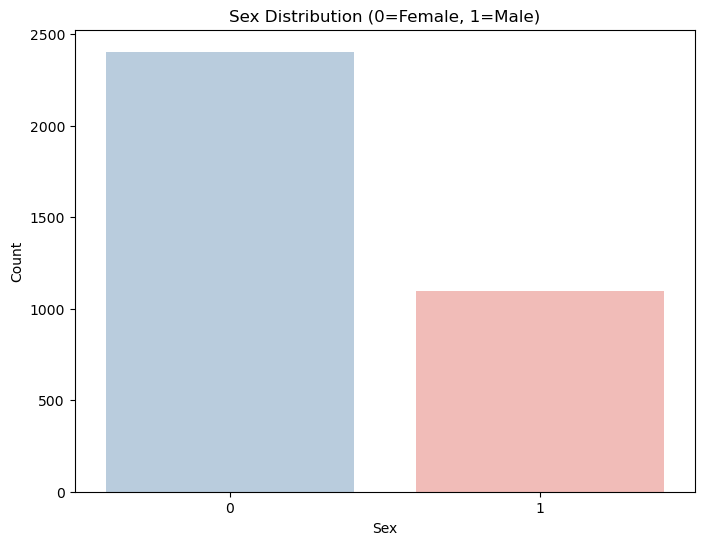

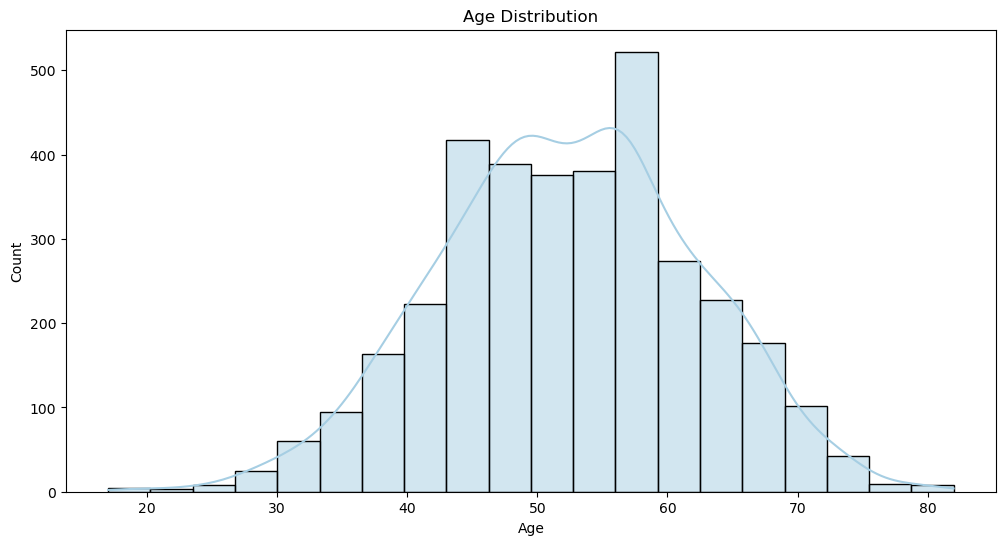

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Cardiac_Catheretization_Diagnosis.csv')

# --- Sex Distribution Bar Chart ---
plt.figure(figsize=(8, 6))
sns.countplot(x='sex', data=df, palette=['#b3cde3', '#fbb4ae'])
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Sex Distribution (0=Female, 1=Male)')
plt.show()

# --- Age Distribution Histogram with KDE ---
plt.figure(figsize=(12, 6))
sns.histplot(df['age'], bins=20, kde=True, color='#a6cee3', alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()


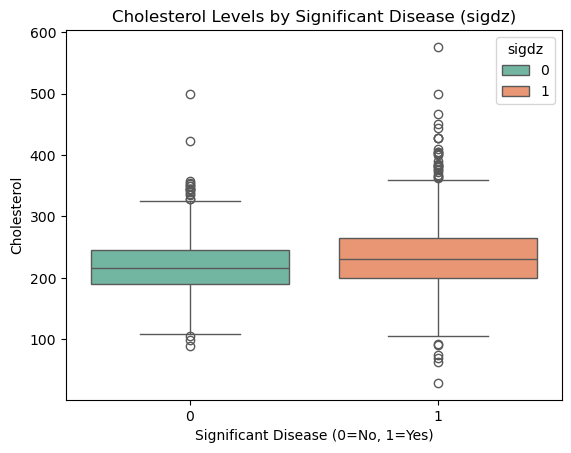

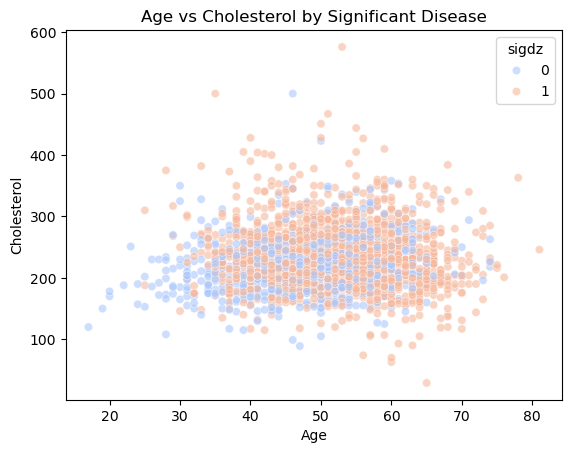

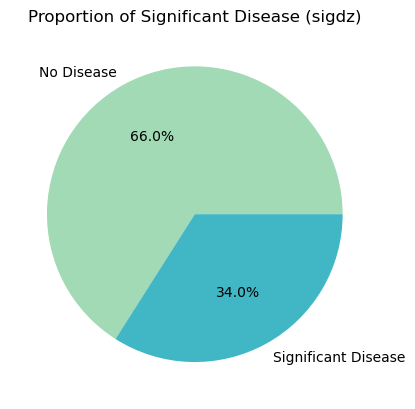

In [11]:
# responses to "help me create visuals to tell story from dataset":


# Cholesterol by significant disease
sns.boxplot(x='sigdz', y='choleste', data=data2, hue = "sigdz", palette='Set2')
plt.title('Cholesterol Levels by Significant Disease (sigdz)')
plt.xlabel('Significant Disease (0=No, 1=Yes)')
plt.ylabel('Cholesterol')
plt.show()

# Age vs Cholesterol by disease status
sns.scatterplot(x='age', y='choleste', hue='sigdz', data=data2, palette='coolwarm', alpha=0.6)
plt.title('Age vs Cholesterol by Significant Disease')
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.show()

# Proportion of significant disease
sigdz_counts = data2['sigdz'].value_counts()
sigdz_counts.plot.pie(autopct='%1.1f%%', labels=['No Disease', 'Significant Disease'], colors=['#a1dab4','#41b6c4'])
plt.title('Proportion of Significant Disease (sigdz)')
plt.ylabel('')
plt.show()


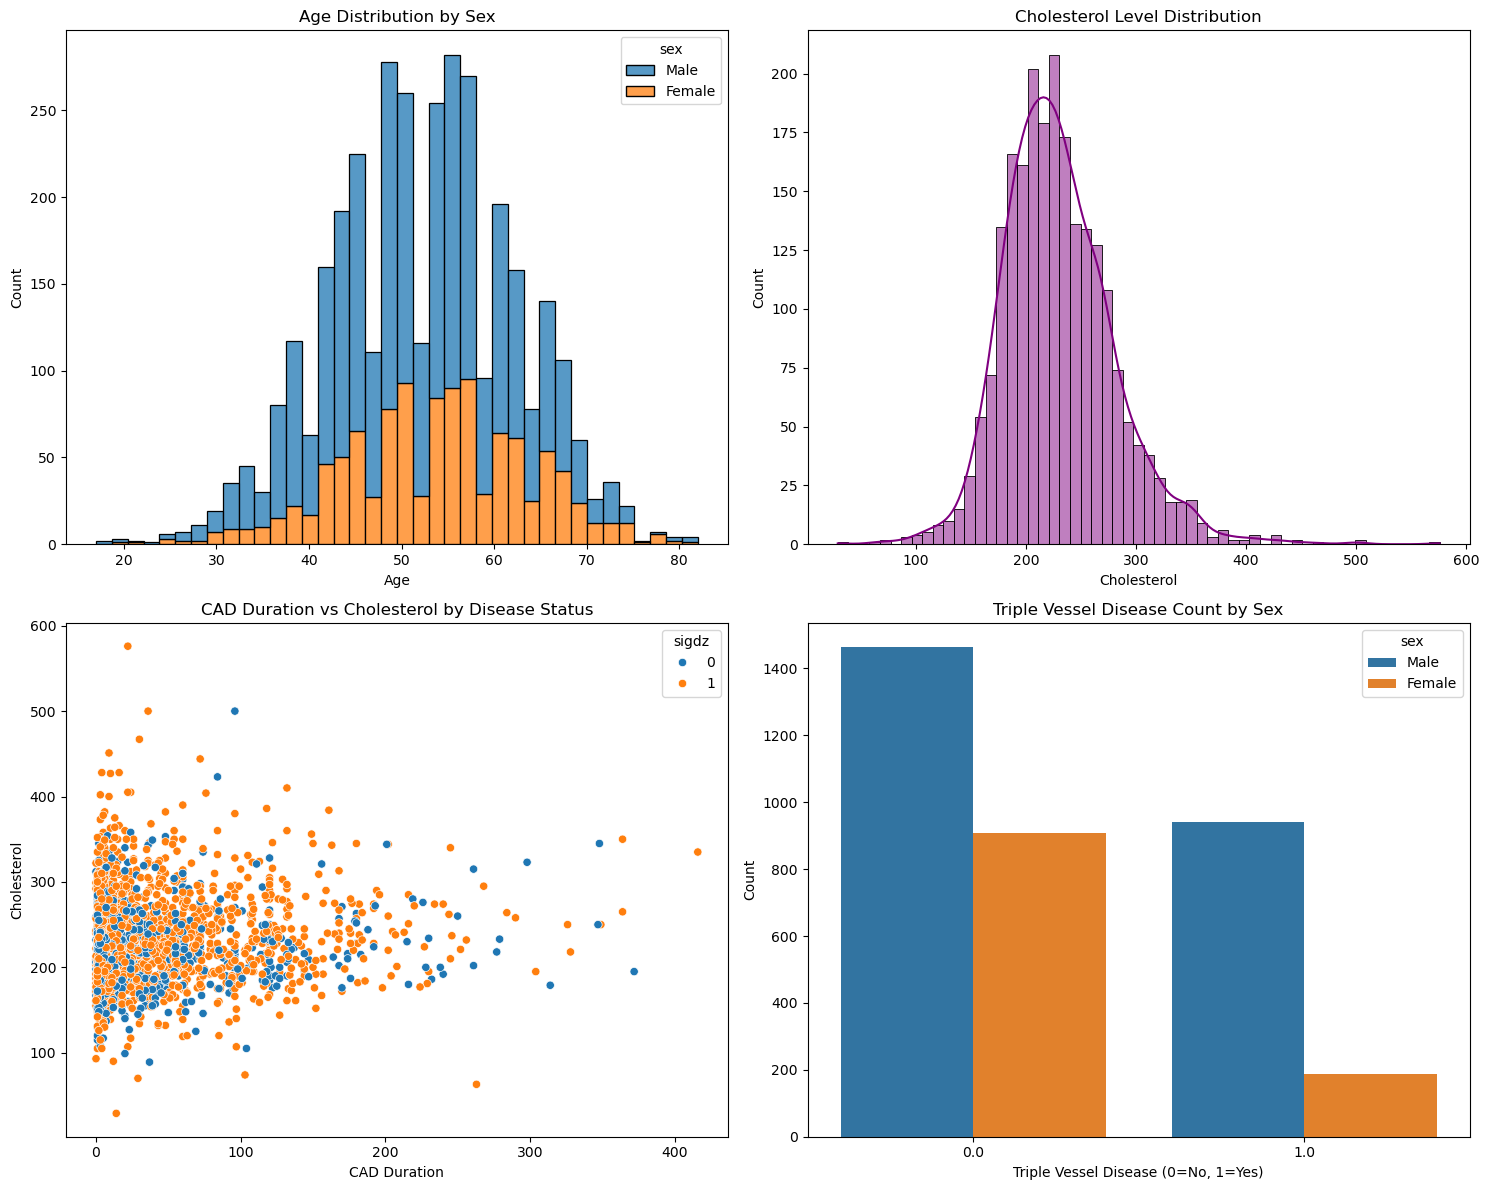

In [7]:
# basic visualizations combined to an overall figure: using Sonar by perplexity - prompt #1:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'Cardiac_Catheretization_Diagnosis.csv'
data = pd.read_csv(file_path)

# Map sex to categorical for better plotting
data['sex'] = data['sex'].map({0: 'Male', 1: 'Female'})

# Prepare figure and subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# 1. Age Distribution by Sex
sns.histplot(data=data, x='age', hue='sex', multiple='stack', ax=axs[0, 0])
axs[0, 0].set_title('Age Distribution by Sex')
axs[0, 0].set_xlabel('Age')
axs[0, 0].set_ylabel('Count')

# 2. Cholesterol Level Distribution
sns.histplot(data=data, x='choleste', kde=True, color='purple', ax=axs[0, 1])
axs[0, 1].set_title('Cholesterol Level Distribution')
axs[0, 1].set_xlabel('Cholesterol')
axs[0, 1].set_ylabel('Count')

# 3. CAD Duration vs Cholesterol by Disease Status
sns.scatterplot(data=data, x='cad.dur', y='choleste', hue='sigdz', ax=axs[1, 0])
axs[1, 0].set_title('CAD Duration vs Cholesterol by Disease Status')
axs[1, 0].set_xlabel('CAD Duration')
axs[1, 0].set_ylabel('Cholesterol')

# 4. Triple Vessel Disease Count by Sex
sns.countplot(data=data, x='tvdlm', hue='sex', ax=axs[1, 1])
axs[1, 1].set_title('Triple Vessel Disease Count by Sex')
axs[1, 1].set_xlabel('Triple Vessel Disease (0=No, 1=Yes)')
axs[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()


/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_10239/4211397370.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0,0].legend(title='Sex')


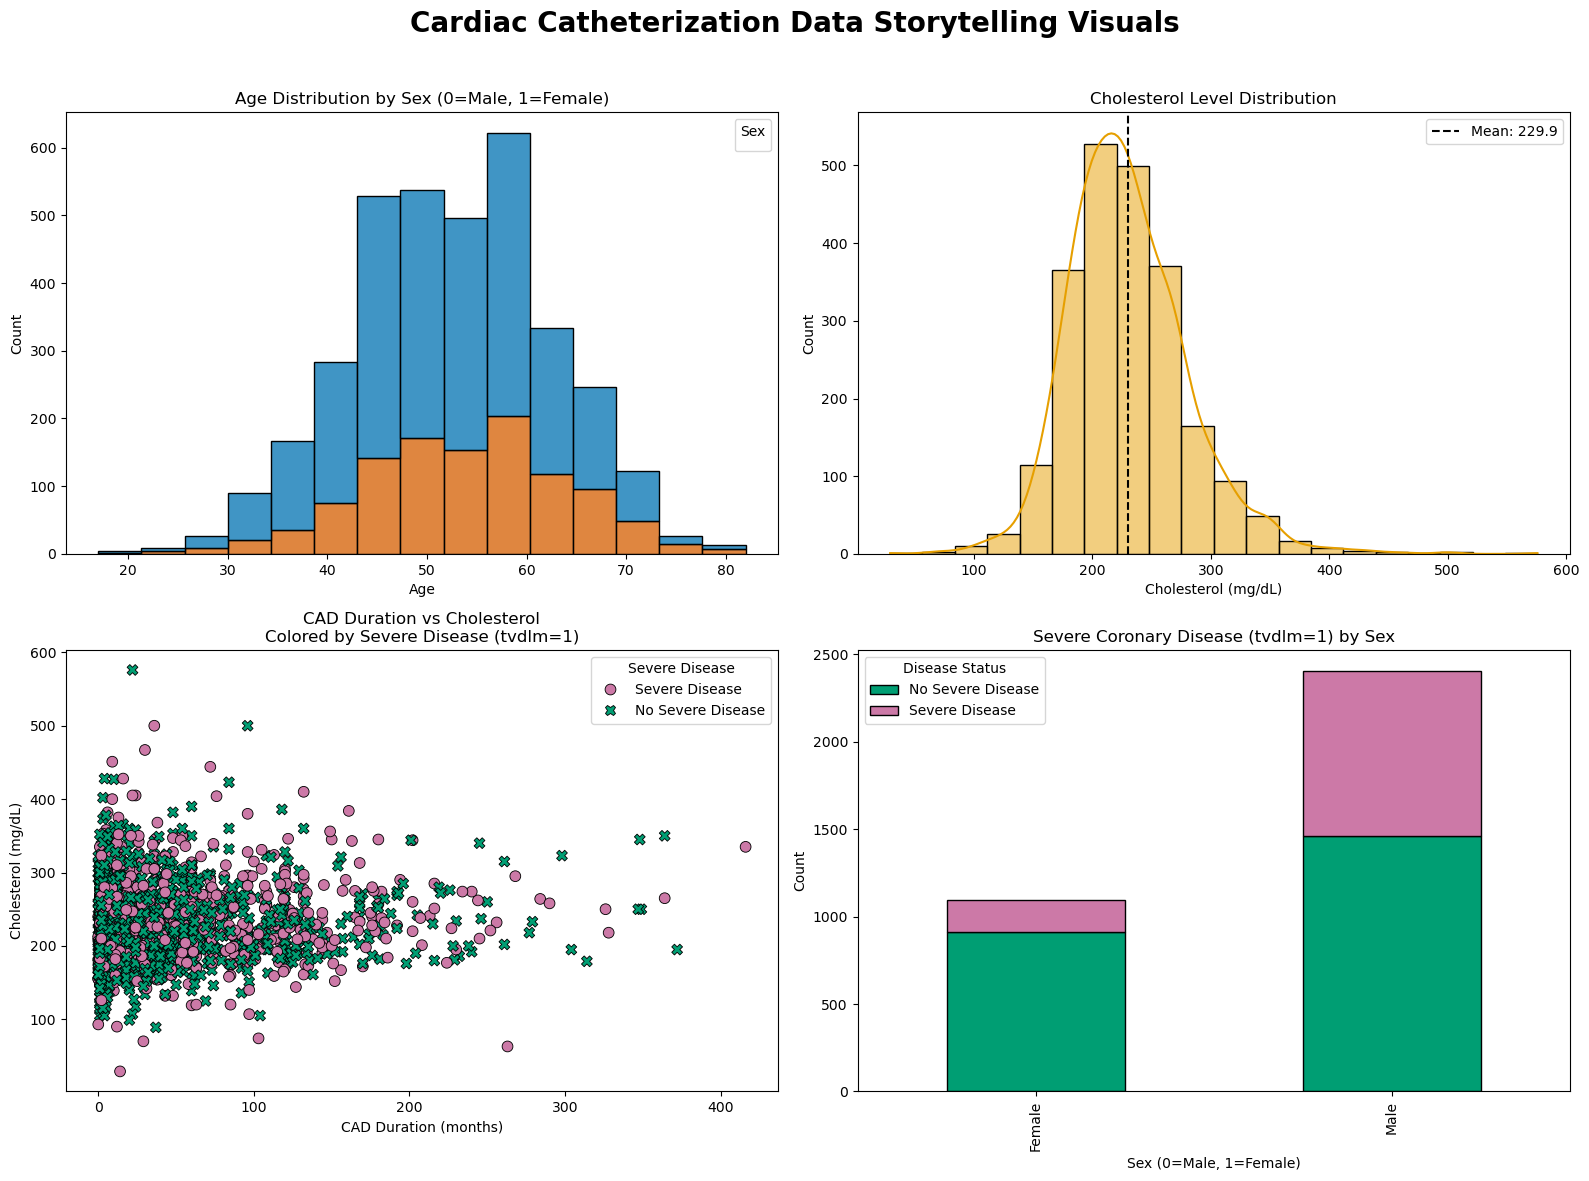

In [5]:
# initial prompt:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_csv('Cardiac_Catheretization_Diagnosis.csv')

# Prepare data
sex_map = {0: 'Male', 1: 'Female'}
df['sex_label'] = df['sex'].map(sex_map)
df['severe_dz'] = df['tvdlm'].map({0: 'No Severe Disease', 1: 'Severe Disease'})

# Set up color palette
palette_sex = {'Male': '#0072B2', 'Female': '#D55E00'}  # Colorblind-friendly
palette_severe = {'No Severe Disease': '#009E73', 'Severe Disease': '#CC79A7'}

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Cardiac Catheterization Data Storytelling Visuals', fontsize=20, fontweight='bold')

# 1. Age Distribution by Sex
sns.histplot(data=df, x='age', hue='sex_label', multiple='stack', bins=15,
             palette=palette_sex, edgecolor='black', ax=axs[0,0])
axs[0,0].set_title('Age Distribution by Sex (0=Male, 1=Female)')
axs[0,0].set_xlabel('Age')
axs[0,0].set_ylabel('Count')
axs[0,0].legend(title='Sex')

# 2. Cholesterol Distribution
sns.histplot(df['choleste'].dropna(), bins=20, color='#E69F00', edgecolor='black', ax=axs[0,1], kde=True)
axs[0,1].set_title('Cholesterol Level Distribution')
axs[0,1].set_xlabel('Cholesterol (mg/dL)')
axs[0,1].set_ylabel('Count')
mean_chol = df['choleste'].mean()
axs[0,1].axvline(mean_chol, color='k', linestyle='--', label=f'Mean: {mean_chol:.1f}')
axs[0,1].legend()

# 3. CAD Duration vs Cholesterol by Severe Disease
sns.scatterplot(data=df, x='cad.dur', y='choleste', hue='severe_dz',
                palette=palette_severe, style='severe_dz', ax=axs[1,0], s=60, edgecolor='black')
axs[1,0].set_title('CAD Duration vs Cholesterol\nColored by Severe Disease (tvdlm=1)')
axs[1,0].set_xlabel('CAD Duration (months)')
axs[1,0].set_ylabel('Cholesterol (mg/dL)')
axs[1,0].legend(title='Severe Disease')

# 4. Severe Disease Count by Sex
severe_counts = df.groupby(['sex_label', 'tvdlm']).size().unstack(fill_value=0)
severe_counts = severe_counts.rename(columns={0: 'No Severe Disease', 1: 'Severe Disease'})
severe_counts[['No Severe Disease', 'Severe Disease']].plot(kind='bar',
    stacked=True, color=[palette_severe['No Severe Disease'], palette_severe['Severe Disease']],
    edgecolor='black', ax=axs[1,1])
axs[1,1].set_title('Severe Coronary Disease (tvdlm=1) by Sex')
axs[1,1].set_xlabel('Sex (0=Male, 1=Female)')
axs[1,1].set_ylabel('Count')
axs[1,1].legend(title='Disease Status')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


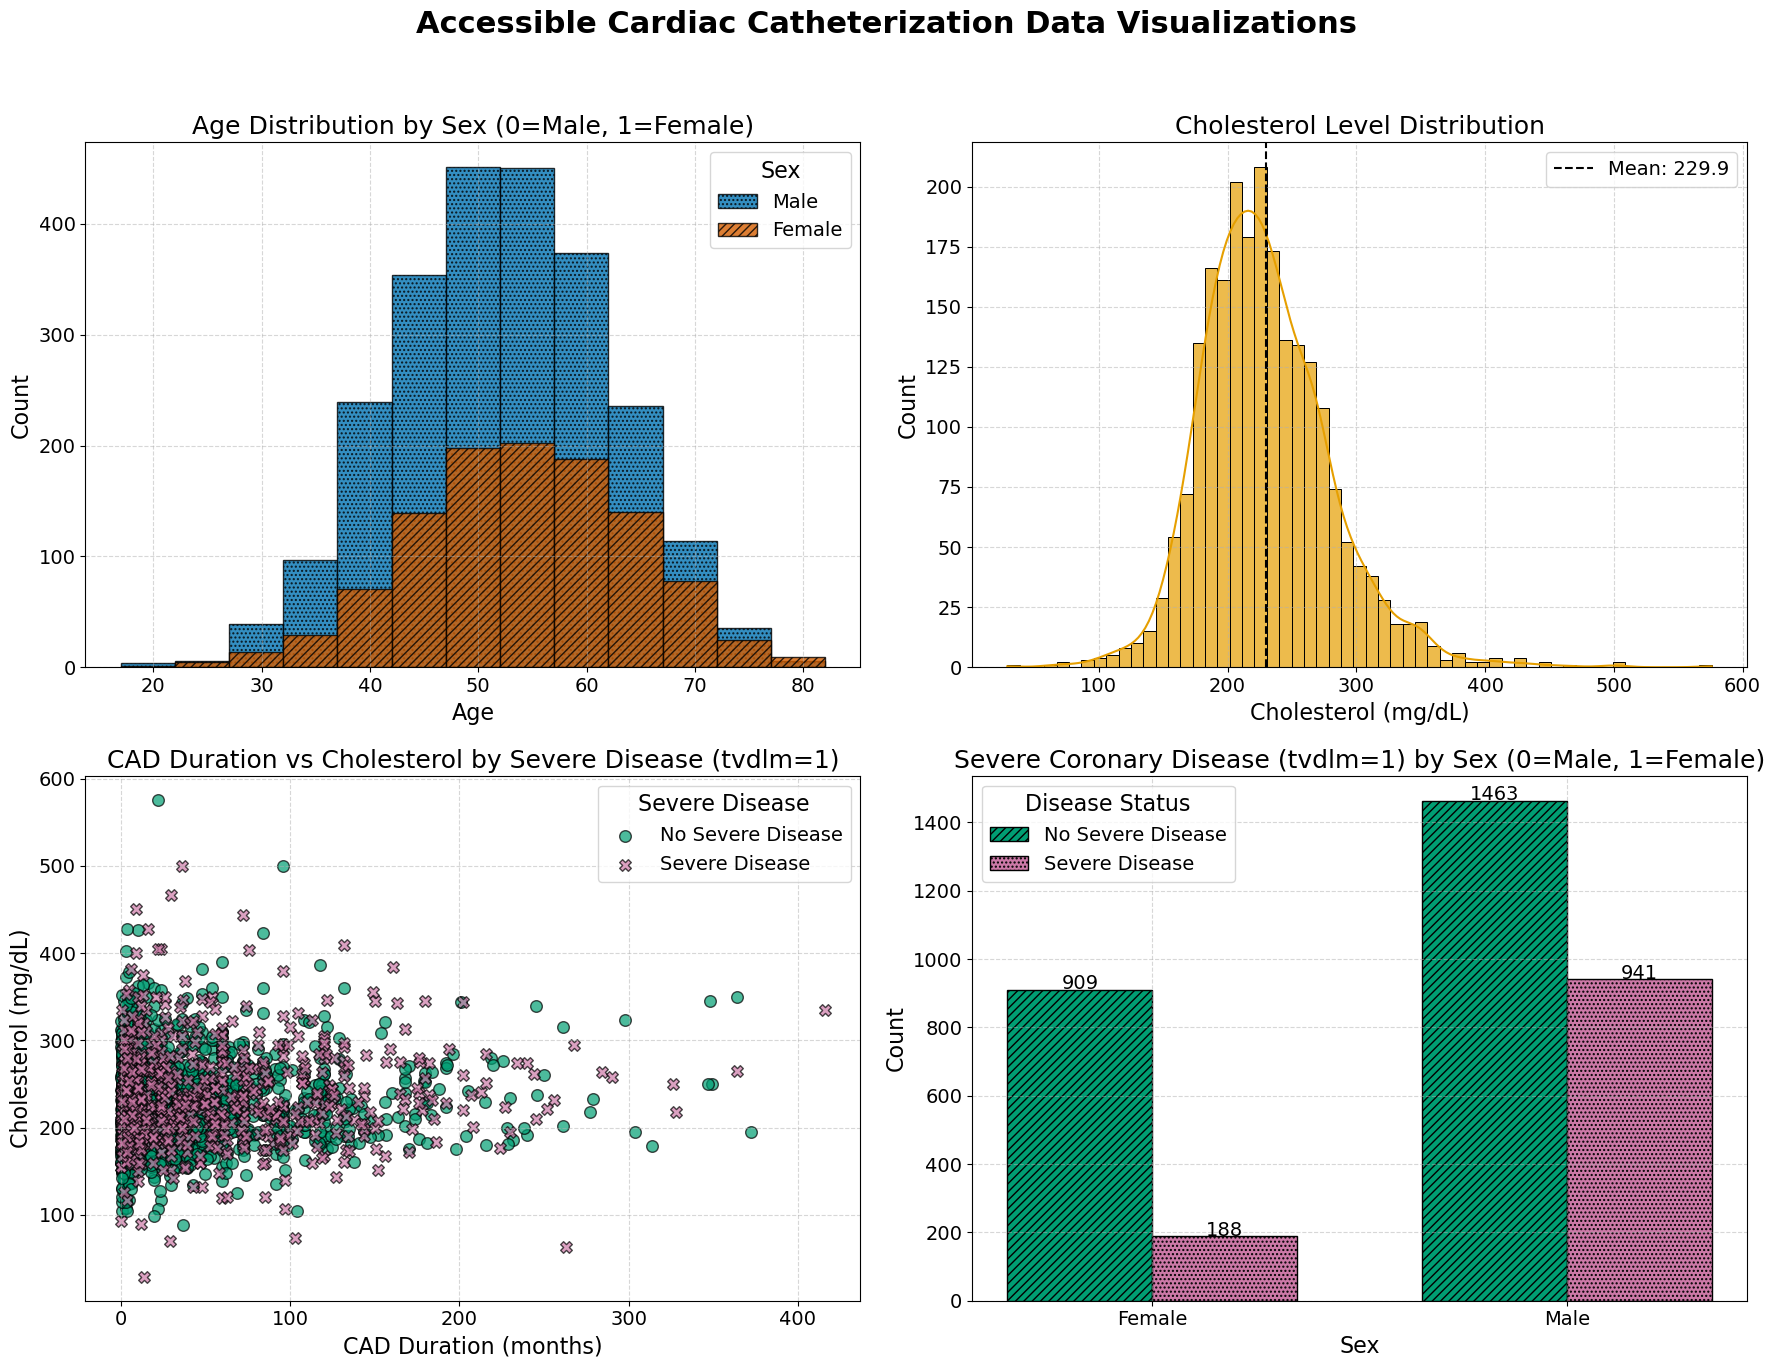

In [9]:
# perplexity accessibility enhancements - prompt #2: 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_csv('Cardiac_Catheretization_Diagnosis.csv')

# Prepare data
sex_map = {0: 'Male', 1: 'Female'}
df['sex_label'] = df['sex'].map(sex_map)
df['severe_dz'] = df['tvdlm'].map({0: 'No Severe Disease', 1: 'Severe Disease'})

# Set global font size and style for accessibility
plt.rcParams.update({
    'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16,
    'legend.fontsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14
})

# Accessible color palettes
palette_sex = {'Male': '#0072B2', 'Female': '#D55E00'}  # Blue and orange
palette_severe = {'No Severe Disease': '#009E73', 'Severe Disease': '#CC79A7'}  # Green and pink

fig, axs = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Accessible Cardiac Catheterization Data Visualizations', fontsize=22, fontweight='bold')

# 1. Age Distribution by Sex with hatching and edge color
bins = np.arange(df['age'].min(), df['age'].max() + 5, 5)
for i, sex in enumerate(df['sex_label'].unique()):
    subset = df[df['sex_label'] == sex]
    axs[0, 0].hist(subset['age'], bins=bins, 
                   color=palette_sex[sex], 
                   alpha=0.8, 
                   label=sex, 
                   edgecolor='black',
                   hatch='////' if sex == 'Female' else '....')
axs[0, 0].set_title('Age Distribution by Sex (0=Male, 1=Female)')
axs[0, 0].set_xlabel('Age')
axs[0, 0].set_ylabel('Count')
axs[0, 0].legend(title='Sex', loc='upper right')
axs[0, 0].grid(True, linestyle='--', alpha=0.5)

# 2. Cholesterol Level Distribution with mean annotation and grid
chol = df['choleste'].dropna()
sns.histplot(chol, kde=True, color='#E69F00', alpha=0.7, ax=axs[0, 1], edgecolor='black')
axs[0, 1].set_title('Cholesterol Level Distribution')
axs[0, 1].set_xlabel('Cholesterol (mg/dL)')
axs[0, 1].set_ylabel('Count')
mean_chol = chol.mean()
axs[0, 1].axvline(mean_chol, color='k', linestyle='--', label=f'Mean: {mean_chol:.1f}')
axs[0, 1].legend()
axs[0, 1].grid(True, linestyle='--', alpha=0.5)

# 3. CAD Duration vs Cholesterol by Severe Disease with distinct markers and edge color
markers = {'No Severe Disease': 'o', 'Severe Disease': 'X'}
for status, marker in markers.items():
    subset = df[df['severe_dz'] == status]
    axs[1, 0].scatter(subset['cad.dur'], subset['choleste'], 
                      label=status, 
                      color=palette_severe[status],
                      marker=marker, alpha=0.7, edgecolor='black', s=70)
axs[1, 0].set_title('CAD Duration vs Cholesterol by Severe Disease (tvdlm=1)')
axs[1, 0].set_xlabel('CAD Duration (months)')
axs[1, 0].set_ylabel('Cholesterol (mg/dL)')
axs[1, 0].legend(title='Severe Disease')
axs[1, 0].grid(True, linestyle='--', alpha=0.5)

# 4. Severe Disease Count by Sex with hatching and direct labels
severe_counts = df.groupby(['sex_label', 'tvdlm']).size().unstack(fill_value=0)
severe_counts = severe_counts.rename(columns={0: 'No Severe Disease', 1: 'Severe Disease'})
bar_width = 0.35
x = np.arange(len(severe_counts.index))
for i, sex in enumerate(severe_counts.index):
    bars_no = axs[1, 1].bar(x[i] - bar_width/2, severe_counts.loc[sex, 'No Severe Disease'], 
                            width=bar_width, color=palette_severe['No Severe Disease'], 
                            edgecolor='black', hatch='////')
    bars_yes = axs[1, 1].bar(x[i] + bar_width/2, severe_counts.loc[sex, 'Severe Disease'], 
                             width=bar_width, color=palette_severe['Severe Disease'], 
                             edgecolor='black', hatch='....')
    # Add direct labels
    axs[1, 1].text(x[i] - bar_width/2, severe_counts.loc[sex, 'No Severe Disease'] + 2, 
                   f"{severe_counts.loc[sex, 'No Severe Disease']}", ha='center', fontsize=14)
    axs[1, 1].text(x[i] + bar_width/2, severe_counts.loc[sex, 'Severe Disease'] + 2, 
                   f"{severe_counts.loc[sex, 'Severe Disease']}", ha='center', fontsize=14)

axs[1, 1].set_xticks(x)
axs[1, 1].set_xticklabels(severe_counts.index)
axs[1, 1].set_title('Severe Coronary Disease (tvdlm=1) by Sex (0=Male, 1=Female)')
axs[1, 1].set_xlabel('Sex')
axs[1, 1].set_ylabel('Count')
axs[1, 1].legend(['No Severe Disease', 'Severe Disease'], title='Disease Status')
axs[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
